# Final Examination: TranslateAI Ancient Character Recognition

Total Marks: 100

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.

In [1]:
# Enter your course email here
student_email = "shaon.iit52@gmail.com"

---

## 📖 TranslateAI — Digitizing History

You have just been hired as a Machine Learning Engineer at **TranslateAI**, a startup working with international museums. Your first task is to build a neural network that can automatically classify ancient Japanese cursive texts.

We will use the **KMNIST** dataset — 28x28 grayscale images of 10 cursive characters: *o, ki, su, tsu, na, ha, ma, ya, re, wo*.

To ensure top performance, you must optimize your deep learning pipeline using **Batch Normalization** and **Advanced Optimizers (Adam)**.

---

## Question 1: Load, Explore, & Preprocess Data (20 Marks)

### 1.1 Download the Dataset (5 Marks)

We will use `torchvision.datasets.KMNIST` to download the dataset.

Run the cell below to download the training and test sets:

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Class names for KMNIST
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# Download KMNIST
full_train_dataset = torchvision.datasets.KMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.KMNIST(root='./data', train=False, download=True)

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")

100%|██████████| 18.2M/18.2M [00:17<00:00, 1.03MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 182kB/s]
100%|██████████| 3.04M/3.04M [00:01<00:00, 1.86MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 3.26MB/s]

Training set size: 60000
Test set size: 10000


In [6]:
image, label = full_train_dataset[0]

print(type(image))
print(type(label))

<class 'PIL.Image.Image'>
<class 'int'>


### 1.2 Visualize Sample Grayscale Images (5 Marks)

Create a **2x5 subplot figure** (figsize 12x5) showing one sample image from **each of the 10 classes**.
- Title each subplot with its class name
- Turn off axis ticks
- Ensure you use `cmap='gray'` for visualization.

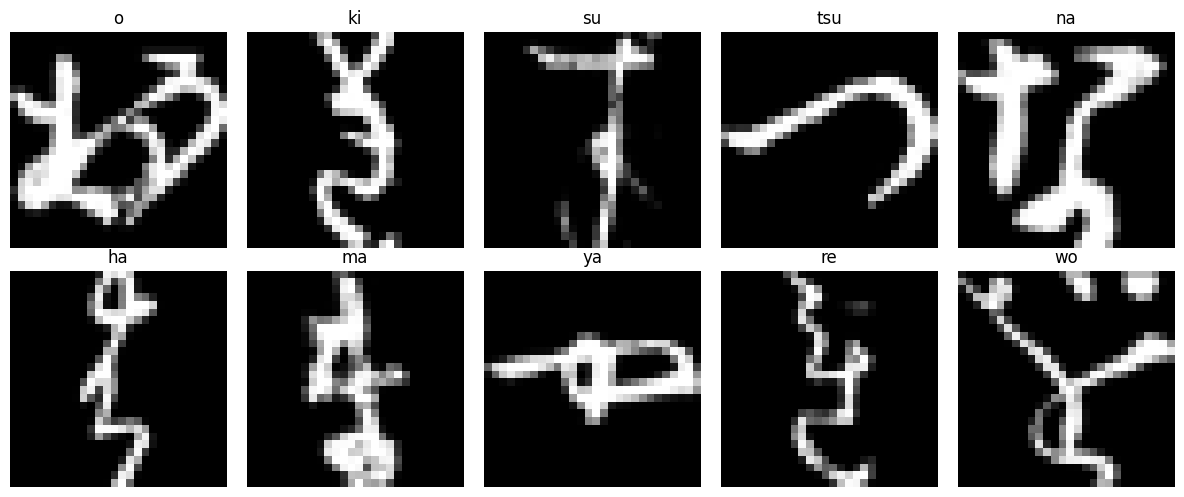

In [15]:
# YOUR CODE HERE
class_name = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

fig, axes = plt.subplots(2, 5, figsize=(12,5))

class_count = 0

for image, label in full_train_dataset:
  if label == class_count:
    ax = axes.flat[class_count]

    ax.imshow(image, cmap='gray')
    ax.set_title(f'{class_name[label]}')
    ax.axis('off')

    class_count += 1

    if class_count == 10:
      break

plt.tight_layout()
plt.show()

### 1.3 Data Scaling & Splitting (10 Marks)

**Your tasks:**
1. Extract images and labels from both train and test datasets as NumPy arrays. (Note: KMNIST images are 28x28)
2. Normalize the pixel values to the range [0, 1] by MinMax Scaling.
3. Split the training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
4. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (float32 tensors), `y_train, y_val, y_test` (long tensors)

In [16]:
# YOUR CODE HERE

train_images = []
train_labels = []

test_images = []
test_labels = []

for image, label in full_train_dataset:
  train_images.append(np.array(image))
  train_labels.append(np.array(label))

X = np.array(train_images)
y = np.array(train_labels)

for image, label in test_dataset_raw:
  test_images.append(np.array(image))
  test_labels.append(np.array(label))

Xt = np.array(train_images)
yt = np.array(train_labels)

X =  X / 255
Xt = Xt / 255


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 10000, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

X_test = torch.tensor(Xt, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(yt, dtype=torch.long)

In [17]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28)
assert X_train.dtype == torch.float32
assert y_train.dtype == torch.long
print("✅ Q1.3 Passed!")

✅ Q1.3 Passed!


---

## Question 2: Build PyTorch DataLoaders (15 Marks)

Create `TensorDataset` and `DataLoader` objects for train, validation, and test sets.

- **batch_size = 256**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [18]:
# YOUR CODE HERE

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [19]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (256, 28, 28)
assert batch_y.dtype == torch.long
print("✅ Q2 Passed!")

✅ Q2 Passed!


---

## Question 3: Deep Neural Network Architecture (25 Marks)

Create a class `TranslateAIClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture. Since the input is `28x28`, the flattened size is **784**.

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28x28 → 784 |
| Linear | 784 → 512 |
| BatchNorm1d | Batch Normalization (512 features) |
| ReLU | Activation |
| Linear | 512 → 256 |
| BatchNorm1d | Batch Normalization (256 features) |
| ReLU | Activation |
| Linear | 256 → 128 |
| BatchNorm1d | Batch Normalization (128 features) |
| ReLU | Activation |
| Linear | 128 → 10 |

After defining the class, create an instance called `model` and print it.

In [21]:
# YOUR CODE HERE
class TranslateAIClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),

        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),

        nn.Linear(128, 10)
    )

  def forward(self, x):
    return self.network(x)

model = TranslateAIClassifier()
print(model)

TranslateAIClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [22]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10)
has_batchnorm = any(isinstance(m, nn.BatchNorm1d) for m in model.modules())
assert has_batchnorm, "Model must include BatchNorm1d layers"
print("✅ Q3 Passed!")

✅ Q3 Passed!


---

## Question 4: Advanced Training Pipeline (25 Marks)

### 4.1 Setup Optimizer and Loss (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.Adam` with `lr=0.001`
- Number of epochs: **15**

In [23]:
# YOUR CODE HERE

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15

### 4.2 PyTorch Training Pipeline (20 Marks)

Write the training loop for **15 epochs**.

For each epoch:
1. Set model to training mode (`model.train()`)
2. Train on `train_loader` (forward pass, calculate loss, backward pass, optimizer step)
3. Set model to evaluation mode (`model.eval()`)
4. Evaluate on `val_loader` and compute validation loss and accuracy.
5. Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}`

Store: `train_losses`, `val_losses` lists.

In [25]:
# YOUR CODE HERE
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    total_train_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    average_train_loss = total_train_loss / len(train_loader)

    model.eval()

    total_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:
            outputs = model(images)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    average_val_loss = total_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    train_losses.append(average_train_loss)
    val_losses.append(average_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {average_train_loss:.4f} | Val Loss: {average_val_loss:.4f}")

Epoch 1/15 | Train Loss: 0.3838 | Val Loss: 0.1858
Epoch 2/15 | Train Loss: 0.1351 | Val Loss: 0.1475
Epoch 3/15 | Train Loss: 0.0790 | Val Loss: 0.1485
Epoch 4/15 | Train Loss: 0.0536 | Val Loss: 0.1337
Epoch 5/15 | Train Loss: 0.0340 | Val Loss: 0.1316
Epoch 6/15 | Train Loss: 0.0268 | Val Loss: 0.1475
Epoch 7/15 | Train Loss: 0.0225 | Val Loss: 0.1512
Epoch 8/15 | Train Loss: 0.0187 | Val Loss: 0.1530
Epoch 9/15 | Train Loss: 0.0165 | Val Loss: 0.1562
Epoch 10/15 | Train Loss: 0.0153 | Val Loss: 0.1488
Epoch 11/15 | Train Loss: 0.0196 | Val Loss: 0.1479
Epoch 12/15 | Train Loss: 0.0123 | Val Loss: 0.1399
Epoch 13/15 | Train Loss: 0.0122 | Val Loss: 0.1400
Epoch 14/15 | Train Loss: 0.0108 | Val Loss: 0.1379
Epoch 15/15 | Train Loss: 0.0118 | Val Loss: 0.1379


In [26]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
print("✅ Q4.2 Passed!")

✅ Q4.2 Passed!


---

## Question 5: Evaluation & Analytics (10 Marks)

### 5.1 Test Evaluation (5 Marks)
Evaluate the model on the **test set**.
- Print the Test Accuracy.
- Collect Test dataset's all predictions into a list called `all_preds`.

In [27]:
# YOUR CODE HERE
model.eval()

all_preds = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.tolist())

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.31%


### 5.2 Plot Learning Curves (5 Marks)
Plot **Training Loss** and **Validation Loss** on the same figure across epochs. Include a legend and title.

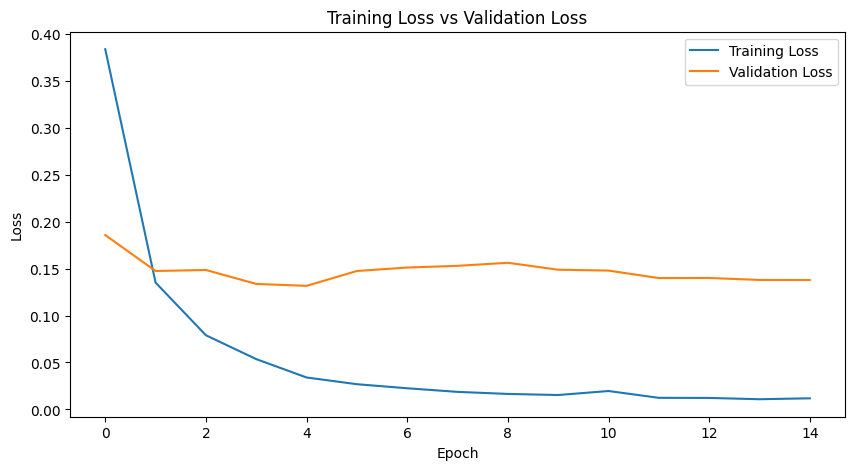

In [28]:
# YOUR CODE HERE
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()

plt.show()

### 5.3 Confusion Matrix & Analysis (5+5 Marks)
1. Plot the confusion matrix using `ConfusionMatrixDisplay`.
2. Write a brief markdown explanation of which ancient character classes are most frequently confused by the model based on the matrix.

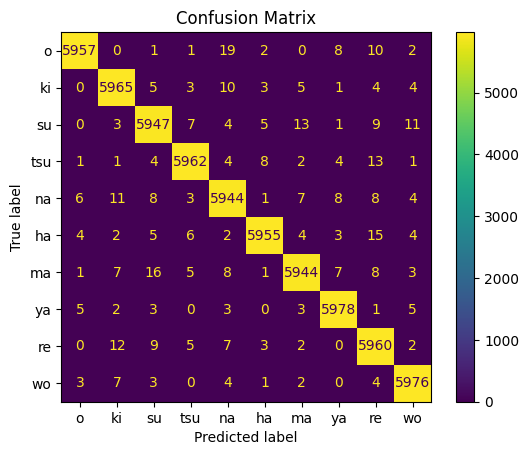

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE

cm = confusion_matrix(y_test, all_preds)

cm_dis = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

cm_dis.plot()
plt.title("Confusion Matrix")
plt.show()

*Double-click here to write your analysis*

**Your Analysis:** Here test accuracy is very high almost 99.5% accuracy. Here with o to na is missclassified 19, ma to su is 16, and some others 15,13, 12, 11, 10.

But overall this model classifies the ancient character very well. O to na and ma to su is more confusion because of similarities in the visual patterns on some characters.

